In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

# For horizontal gridlines to help reading values
sns.set_style("whitegrid") 
# To set default size of plots to avoid repetitive code
plt.rcParams["figure.figsize"] = (10, 6) 

In [5]:
data_frame = pd.read_csv("Coffe_sales.csv")

Phase 1: Explore the Data

In [6]:
# Display top 10 rows
data_frame.head(10)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
5,15,card,33.8,Americano with Milk,Afternoon,Fri,Mar,5,3,2024-03-01,15:39:47.726000
6,16,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,16:19:02.756000
7,18,card,33.8,Americano with Milk,Night,Fri,Mar,5,3,2024-03-01,18:39:03.580000
8,19,card,38.7,Cocoa,Night,Fri,Mar,5,3,2024-03-01,19:22:01.762000
9,19,card,33.8,Americano with Milk,Night,Fri,Mar,5,3,2024-03-01,19:23:15.887000


In [7]:
# Display column names and data types
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [8]:
# Descriptive statistics by column
data_frame.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [9]:
# List the columns
data_frame.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [10]:
# Number of rows/columns
data_frame.shape

(3547, 11)

In [11]:
# Count of missing values
data_frame.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

Phase 2: Basic Business Insights

In [12]:
# How many sales in the dataset? 
print("There are ", len(data_frame), "sales in the dataset!")

There are  3547 sales in the dataset!


In [13]:
# Date range covered by the dataset?
print("The dataset shows sales made between", data_frame["Date"].min(), "and", data_frame["Date"].max()) 

The dataset shows sales made between 2024-03-01 and 2025-03-23


In [14]:
# Types of drinks sold?
print("The dataset shows sales of the following types of drinks: ", data_frame["coffee_name"].unique())

The dataset shows sales of the following types of drinks:  ['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino']


In [15]:
# Highest selling drink?
data_frame["coffee_name"].value_counts()

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

In [16]:
# Most common payment method?
data_frame["cash_type"].value_counts()

cash_type
card    3547
Name: count, dtype: int64

Phase 3: Advanced Insights with Pandas

In [17]:
# Which coffee generated the most revenue? 
data_frame.groupby("coffee_name")["money"].sum().reset_index().sort_values(by = "money") 

,coffee_name,money
5,Espresso,2690.28
4,Cortado,7384.86
3,Cocoa,8521.16
6,Hot Chocolate,9933.46
0,Americano,14650.26
2,Cappuccino,17439.14
1,Americano with Milk,24751.12
7,Latte,26875.30


In [18]:
# Average spend per coffee type
data_frame.groupby("coffee_name")["money"].mean()

coffee_name
Americano              25.975638
Americano with Milk    30.594710
Cappuccino             35.883004
Cocoa                  35.653389
Cortado                25.731220
Espresso               20.854884
Hot Chocolate          35.990797
Latte                  35.502378
Name: money, dtype: float64

In [19]:
# Revenue by day?
data_frame.groupby("Weekday")["money"].sum()

Weekday
Fri    16802.66
Mon    17363.10
Sat    14733.52
Sun    13336.06
Thu    16091.40
Tue    18168.38
Wed    15750.46
Name: money, dtype: float64

Phase 4: Data Visualisation

<Axes: xlabel='coffee_name', ylabel='count'>

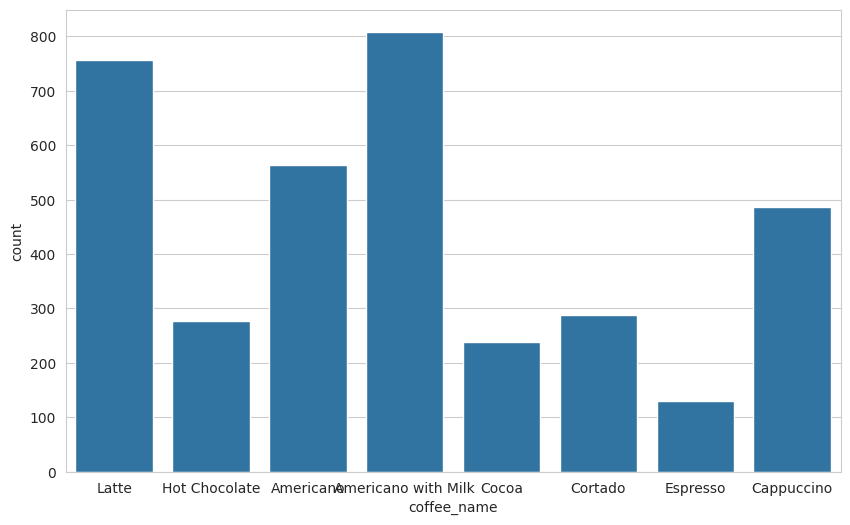

In [22]:
# Make a countplot of the sales by drink type - ideal for counting categories
sns.countplot(data = data_frame, x = "coffee_name")

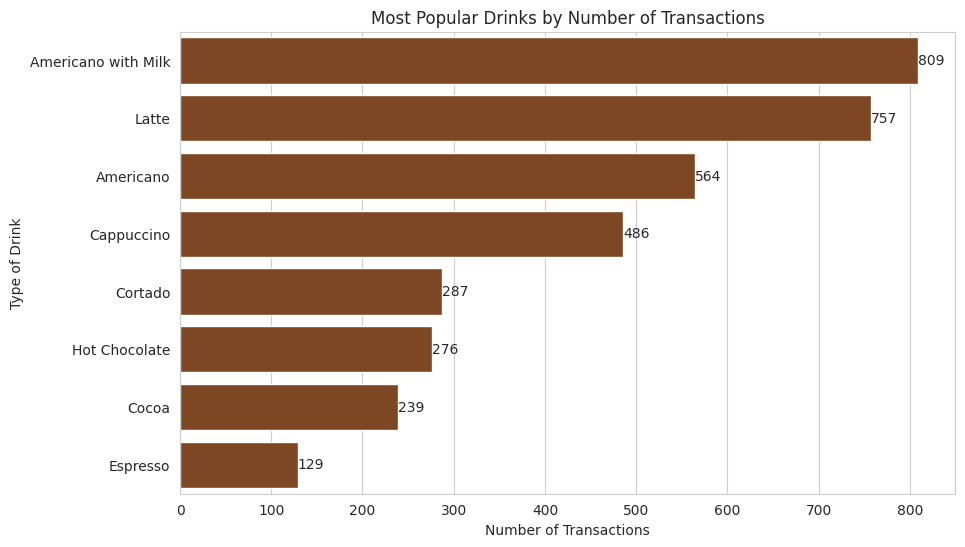

In [34]:
# Which drink is most popular by number of sales?
plot_1 = sns.countplot(data = data_frame, 
              y = "coffee_name", 
              color = "saddlebrown",
              order = data_frame["coffee_name"].value_counts().index)
plt.title("Most Popular Drinks by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Type of Drink")

plt.bar_label(plot_1.containers[0])

plt.show()

In [37]:
# Which drink generates the most revenue? 
revenue = data_frame.groupby("coffee_name")["money"].sum().sort_values(ascending = False) 
revenue

coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: money, dtype: float64

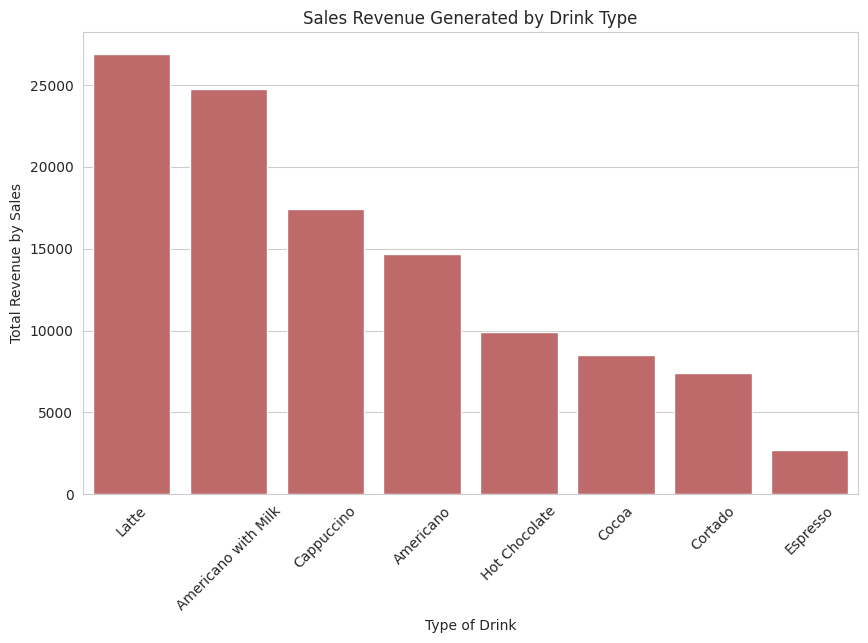

In [40]:
revenue = revenue.reset_index()
sns.barplot(data = revenue, 
            x = "coffee_name", 
            y = "money", 
            color = "indianred")
plt.title("Sales Revenue Generated by Drink Type")
plt.xlabel("Type of Drink")
plt.ylabel("Total Revenue by Sales") 
plt.xticks(rotation = 45)

plt.show()

In [50]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


In [51]:
data_frame["Weekday"].value_counts()

Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64

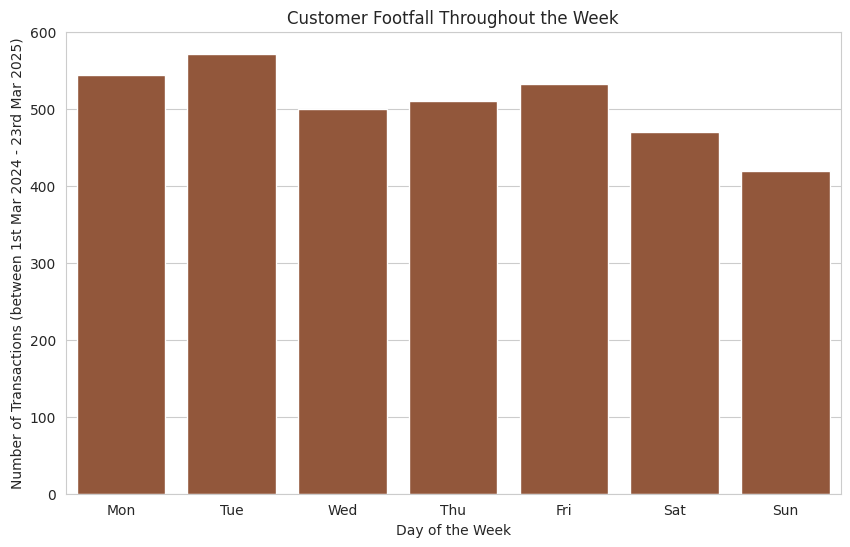

In [56]:
sns.countplot(data = data_frame, 
              x = "Weekday",
              order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
             color = "sienna")
plt.title("Customer Footfall Throughout the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Transactions (between 1st Mar 2024 - 23rd Mar 2025)")
plt.show()